In [ ]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("https://raw.githubusercontent.com/alessio-rizzi/data-science-portfolio/refs/heads/main/machine_learning/dataset/3-clusters.csv")
df2 = pd.read_csv("https://raw.githubusercontent.com/alessio-rizzi/data-science-portfolio/refs/heads/main/machine_learning/dataset/dataset-DBSCAN.csv")
df3 = pd.read_csv("https://raw.githubusercontent.com/alessio-rizzi/data-science-portfolio/refs/heads/main/machine_learning/dataset/CURE-complete.csv")

print("df1 shape:", df1.shape, "columns:", df1.columns.tolist())
print("df2 shape:", df2.shape, "columns:", df2.columns.tolist())
print("df3 shape:", df3.shape, "columns:", df3.columns.tolist())

df1 shape: (150, 2) columns: ['x', 'y']
df2 shape: (6118, 2) columns: ['x', 'y']
df3 shape: (86558, 2) columns: ['x', 'y']


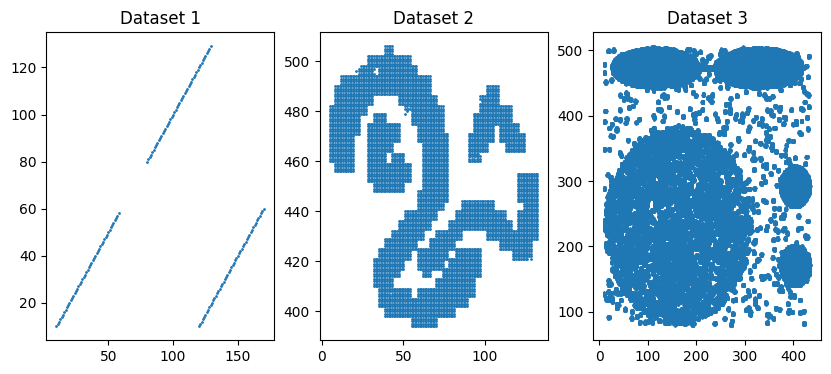

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].scatter(df1.iloc[:,0], df1.iloc[:,1], s=1)
axes[0].set_title('Dataset 1')
axes[1].scatter(df2.iloc[:,0], df2.iloc[:,1], s=1)
axes[1].set_title('Dataset 2')
axes[2].scatter(df3.iloc[:,0], df3.iloc[:,1], s=1)
axes[2].set_title('Dataset 3')
plt.show()

In [10]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Estraiamo i valori numerici e i nomi delle colonne dal DataFrame df1
dataset1 = df1.values
feature_names1 = df1.columns.tolist()

# Impostiamo il seed per la riproducibilità
np.random.seed(5)

# Dal grafico abbiamo dedotto che ci sono 3 cluster separati
k = 3

# Inizializziamo e addestriamo il modello K-Means
kmeans1 = KMeans(n_clusters=k, random_state=0, n_init=10).fit(dataset1)

nrighe_dataset1 = dataset1.shape[0]

# Stampiamo le prime 10 assegnazioni per controllo
print("Prime 10 assegnazioni:")
for i in range(min(10, nrighe_dataset1)):
    print(f"Example n.{i}=({dataset1[i,0]}, {dataset1[i,1]})")
    print(f"in cluster n.{kmeans1.labels_[i]}")

Prime 10 assegnazioni:
Example n.0=(10, 10)
in cluster n.1
Example n.1=(11, 11)
in cluster n.1
Example n.2=(12, 12)
in cluster n.1
Example n.3=(13, 13)
in cluster n.1
Example n.4=(14, 14)
in cluster n.1
Example n.5=(15, 15)
in cluster n.1
Example n.6=(16, 16)
in cluster n.1
Example n.7=(17, 17)
in cluster n.1
Example n.8=(18, 18)
in cluster n.1
Example n.9=(19, 19)
in cluster n.1


In [11]:
# Creiamo una lista di dizionari per popolare il nuovo DataFrame dei risultati
clustering_results_dataset1 = []

for i in range(nrighe_dataset1):
    clustering_results_dataset1.append({
        'Instance': i,
        feature_names1[0]: dataset1[i,0],
        feature_names1[1]: dataset1[i,1],
        'Cluster n.': kmeans1.labels_[i]
    })

# Convertiamo la lista in un DataFrame pandas
results_df1 = pd.DataFrame(clustering_results_dataset1)

# Mostriamo le prime 15 righe del risultato
print("\nPrime 15 righe del DataFrame risultati:")
print(results_df1.head(15).to_string(index=False, float_format='%.1f'))


Prime 15 righe del DataFrame risultati:
 Instance  x  y  Cluster n.
        0 10 10           1
        1 11 11           1
        2 12 12           1
        3 13 13           1
        4 14 14           1
        5 15 15           1
        6 16 16           1
        7 17 17           1
        8 18 18           1
        9 19 19           1
       10 20 20           1
       11 21 21           1
       12 22 22           1
       13 23 23           1
       14 24 24           1


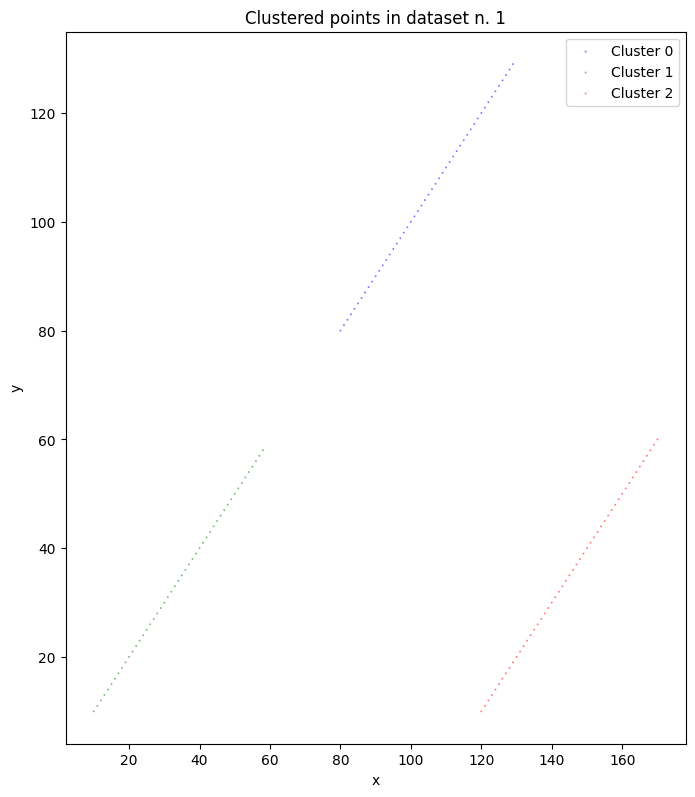

In [12]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111)
fig.subplots_adjust(top=1)
ax.set_title('Clustered points in dataset n. 1')

# Utilizziamo i nomi originali delle colonne estratti dal DataFrame
ax.set_xlabel(feature_names1[0])
ax.set_ylabel(feature_names1[1])

# set the list of colors to be selected when plotting the different clusters
color=['b','g','r','c','m','y','k','w']

# plot the dataset (Ottimizzato con le maschere Booleane di NumPy)
for clu in range(k):
    # Selezioniamo direttamente tutti i punti appartenenti al cluster 'clu'
    mask = (kmeans1.labels_ == clu)
    data_list_x = dataset1[mask, 0]
    data_list_y = dataset1[mask, 1]

    plt.scatter(data_list_x, data_list_y, s=2, edgecolors='none', c=color[clu], alpha=0.5, label=f'Cluster {clu}')

plt.legend()
plt.show()

In [ ]:
# Estraiamo i valori numerici e i nomi delle feature dal DataFrame df2
dataset2 = df2.values
feature_names2 = df2.columns.tolist()
nrighe_dataset2 = dataset2.shape[0]

# Impostiamo il seed per la riproducibilità
np.random.seed(42)

# Scegliamo un K dimostrativo, ad esempio k=4
k2 = 4

# Inizializziamo e addestriamo il modello K-Means sul dataset2
kmeans2 = KMeans(n_clusters=k2, random_state=0, n_init=10).fit(dataset2)

print("Addestramento completato sul Dataset 2.")

In [ ]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
fig.subplots_adjust(top=1)
ax.set_title(f'Clustered points in dataset n. 2 (K={k2})')

ax.set_xlabel(feature_names2[0])
ax.set_ylabel(feature_names2[1])

color=['b','g','r','c','m','y','k','w']

# Plot del dataset utilizzando le maschere booleane per maggiore efficienza
for clu in range(k2):
    mask = (kmeans2.labels_ == clu)
    plt.scatter(dataset2[mask, 0], dataset2[mask, 1], s=2, edgecolors='none', c=color[clu % len(color)], alpha=0.5, label=f'Cluster {clu}')

plt.legend()
plt.show()

**how do you explain what it happens?**

Il risultato mostra chiaramente i limiti dell'algoritmo K-Means. Esso è progettato per funzionare bene su cluster che hanno una forma convessa (sferica), poiché il suo obiettivo è semplicemente minimizzare la distanza lineare (euclidea) dei punti dal centroide più vicino.

Il dataset2, tuttavia, è costituito da forme continue, intrecciate e non convesse. Di conseguenza, l'algoritmo "taglia" ciecamente la figura in blocchi geometrici netti (celle di Voronoi), unendo punti che sono vicini in linea d'aria ma ignorando totalmente la densità reale dei dati e la continuità naturale della struttura. Per dataset di questo tipo, algoritmi basati sulla densità (come DBSCAN) sono l'unica scelta adeguata.

In [15]:
# Estraiamo i valori numerici e i nomi delle feature dal DataFrame df2
dataset3 = df3.values
feature_names3 = df3.columns.tolist()
nrighe_dataset3 = dataset3.shape[0]

# Impostiamo il seed per la riproducibilità
np.random.seed(42)

# Scegliamo un K dimostrativo, ad esempio k=4
k3 = 4

# Inizializziamo e addestriamo il modello K-Means sul dataset2
kmeans3 = KMeans(n_clusters=k3, random_state=0, n_init=10).fit(dataset3)

print("Addestramento completato sul Dataset 3.")

Addestramento completato sul Dataset 3.


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


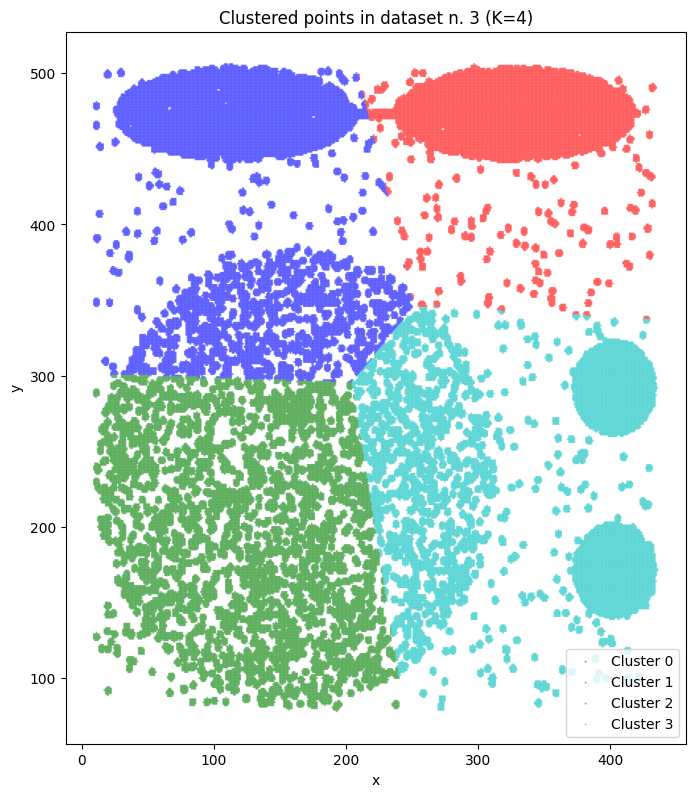

In [16]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
fig.subplots_adjust(top=1)
ax.set_title(f'Clustered points in dataset n. 3 (K={k3})')

ax.set_xlabel(feature_names3[0])
ax.set_ylabel(feature_names3[1])

color=['b','g','r','c','m','y','k','w']

# Plot del dataset utilizzando le maschere booleane per maggiore efficienza
for clu in range(k3):
    mask = (kmeans3.labels_ == clu)
    plt.scatter(dataset3[mask, 0], dataset3[mask, 1], s=2, edgecolors='none', c=color[clu % len(color)], alpha=0.5, label=f'Cluster {clu}')

plt.legend()
plt.show()

**how do you explain what it happens?**

Il K-Means fallisce gravemente su questo dataset (CURE-complete) per due ragioni matematiche fondamentali legate al suo funzionamento:

- incapacità di gestire il rumore (Outliers): Il K-Means impone che ogni singolo punto venga assegnato a un cluster. Non avendo un concetto di "rumore di fondo", l'algoritmo è costretto a incorporare la fitta pioggia di outlier sparsi per il grafico. Questi punti anomali "tirano" i centroidi lontano dai veri addensamenti, sballando completamente le medie.

- assunzione di dimensioni ed estensioni simili: Il K-Means assume implicitamente che i cluster abbiano densità, dimensioni (varianza) e forme simili. In questo dataset abbiamo un cluster sferico enorme in basso a sinistra e cluster molto più piccoli a destra. Nel tentativo di minimizzare la somma degli errori quadratici (SSE), il K-Means "spezza" in modo innaturale il cluster grande in tre fette diverse (blu, verde e azzurro) e accorpa i due piccoli cluster a destra con il resto del rumore.

Conclusione: Per dataset che presentano un forte rumore di fondo e cluster di densità e scale così disomogenee, gli algoritmi basati sulle partizioni (come il K-Means) non sono adatti. È necessario utilizzare algoritmi basati sulla densità locale, come DBSCAN, che sono in grado di etichettare lo spazio vuoto come "rumore" isolando le sole geometrie ad alta densità.

### In the following cells I propose you to write a program that computes with a statistical measure of your choice a quantitative evaluation of clusters in the three datasets.

**Note:**
It is advisable to execute K-means a certain number of times (let us try 10 times) and then select the clustering solution that gives the best value of the evaluation measure.

**Valutazione Quantitativa dei Cluster:** Il Silhouette ScoreIl Silhouette Score è una metrica statistica utilizzata per valutare la qualità e la consistenza di una suddivisione in cluster quando non si dispone di etichette reali (unsupervised learning). Misura quanto un punto sia coeso al proprio gruppo rispetto alla separazione dagli altri cluster.Il calcolo per ogni singolo dato si basa su due parametri fondamentali:Coesione ($a$): La distanza media tra il punto in esame e tutti gli altri punti appartenenti allo stesso cluster. Valori minimi indicano che il cluster è denso e compatto.Separazione ($b$): La distanza media tra il punto e tutti i punti del cluster vicino più prossimo. Valori massimi indicano che il gruppo è ben isolato e distante dagli altri agglomerati.La formula per il coefficiente di Silhouette di un singolo punto è:$$s = \frac{b - a}{\max(a, b)}$$Il punteggio complessivo del modello (Silhouette Score) si ottiene calcolando la media dei coefficienti di tutti i punti del dataset. Il risultato è sempre compreso in un intervallo tra $-1$ e $+1$:Valori vicini a $+1$ (Eccellente): La classificazione è ottimale. I dati sono estremamente vicini ai membri del proprio gruppo e ben distanziati dai cluster adiacenti.Valori attorno a $0$ (Sovrapposizione): I dati si trovano esattamente sul confine decisionale tra due cluster, indicando gruppi non ben separabili o strutture sovrapposte.Valori vicini a $-1$ (Errore): Il clustering è errato. I dati sono stati assegnati al cluster sbagliato, in quanto fisicamente più affini e vicini ai membri di un altro gruppo.

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

def evaluate_best_kmeans(dataset, k, dataset_name, n_runs=10):
    print(f"--- Valutazione {dataset_name} (K={k}) ---")
    best_score = -1
    best_kmeans = None

    for i in range(n_runs):
        # Inizializziamo K-means con un random_state diverso per ogni iterazione
        # n_init=1 forza l'algoritmo a fare un singolo run interno per volta
        km = KMeans(n_clusters=k, init='random', n_init=1, random_state=i)
        labels = km.fit_predict(dataset)

        # Calcoliamo il Silhouette Score.
        # sample_size=5000 garantisce che anche per dataset enormi il calcolo sia immediato.
        score = silhouette_score(dataset, labels, sample_size=5000, random_state=42)

        print(f"Run {i+1}/{n_runs} - Silhouette Score: {score:.4f}")

        # Aggiorniamo il modello migliore se troviamo un punteggio più alto
        if score > best_score:
            best_score = score
            best_kmeans = km

    print(f"--> MIGLIOR MODELLO per {dataset_name}: Silhouette Score = {best_score:.4f}\n")
    return best_kmeans, best_score

# Definiamo i K scelti precedentemente (o scelti per l'analisi)
k1 = 3
k2 = 4
k3 = 4

# 1. Valutazione Dataset 1
best_model_1, best_score_1 = evaluate_best_kmeans(df1, k1, "Dataset 1")

# 2. Valutazione Dataset 2
best_model_2, best_score_2 = evaluate_best_kmeans(df2, k2, "Dataset 2")

# 3. Valutazione Dataset 3
best_model_3, best_score_3 = evaluate_best_kmeans(df3, k3, "Dataset 3")

--- Valutazione Dataset 1 (K=3) ---
Run 1/10 - Silhouette Score: 0.7229
Run 2/10 - Silhouette Score: 0.7229
Run 3/10 - Silhouette Score: 0.7229
Run 4/10 - Silhouette Score: 0.7229
Run 5/10 - Silhouette Score: 0.7229
Run 6/10 - Silhouette Score: 0.7229
Run 7/10 - Silhouette Score: 0.4109
Run 8/10 - Silhouette Score: 0.7229
Run 9/10 - Silhouette Score: 0.7229
Run 10/10 - Silhouette Score: 0.7229
--> MIGLIOR MODELLO per Dataset 1: Silhouette Score = 0.7229

--- Valutazione Dataset 2 (K=4) ---
Run 1/10 - Silhouette Score: 0.4160
Run 2/10 - Silhouette Score: 0.4399
Run 3/10 - Silhouette Score: 0.4400
Run 4/10 - Silhouette Score: 0.4160
Run 5/10 - Silhouette Score: 0.4161
Run 6/10 - Silhouette Score: 0.4401
Run 7/10 - Silhouette Score: 0.4178
Run 8/10 - Silhouette Score: 0.4401
Run 9/10 - Silhouette Score: 0.4160
Run 10/10 - Silhouette Score: 0.4177
--> MIGLIOR MODELLO per Dataset 2: Silhouette Score = 0.4401

--- Valutazione Dataset 3 (K=4) ---
Run 1/10 - Silhouette Score: 0.4102
Run 2/10 -

Calcolo dei Silhouette Score in corso...


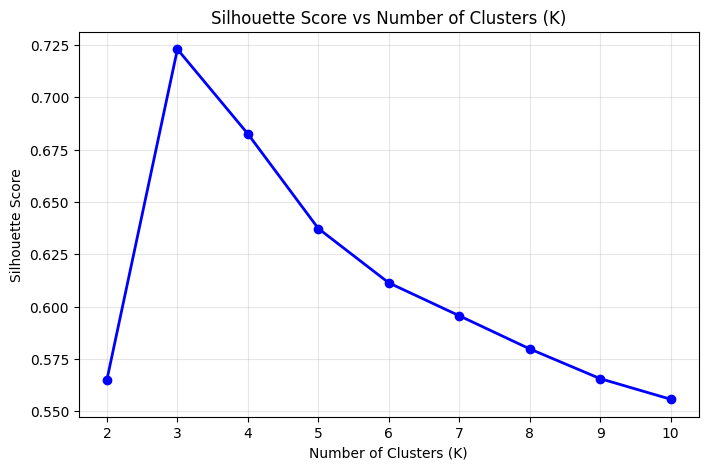


Il valore ottimale di K (quello con il picco più alto nel grafico) è: 3


In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Definiamo il range di K da testare (la Silhouette richiede almeno K=2)
k_values = range(2, 11)
silhouette_scores = []

print("Calcolo dei Silhouette Score in corso...")

# Eseguiamo il ciclo sul Dataset 1 (puoi cambiare la variabile in dataset2 o dataset3 se preferisci)
for k in k_values:
    # Addestramento del modello per il K corrente
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(dataset1)

    # Calcolo del Silhouette Score (usiamo un sample se il dataset è enorme, ma dataset1 è piccolo)
    score = silhouette_score(dataset1, labels)
    silhouette_scores.append(score)

# Visualizzazione grafica dei risultati
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Silhouette Score vs Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

# Identificazione automatica del K migliore
best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nIl valore ottimale di K (quello con il picco più alto nel grafico) è: {best_k}")

### In the following cell I propose you to run DBSCAN, instead, on one of the last two datasets: either dataset2 or dataset3.

At the beginning try using a pair of Minpts and Eps of your choice.

**Note:**
If the data is too big, **sample it random, using a factor of 0.1.**

Punti originali: 86558 | Punti dopo il campionamento: 8655


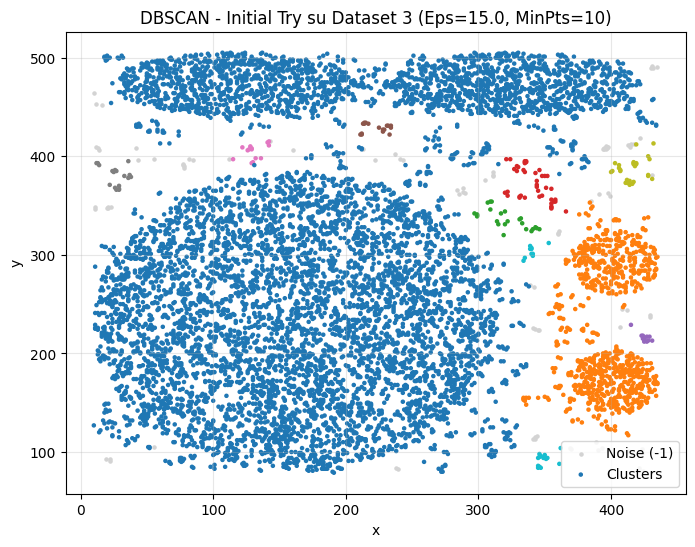

In [20]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# 1. Campionamento casuale del dataset al 10% (fattore 0.1)
np.random.seed(42)
sample_factor = 0.1
sample_size = int(dataset3.shape[0] * sample_factor)
sample_indices = np.random.choice(dataset3.shape[0], size=sample_size, replace=False)
dataset3_sampled = dataset3[sample_indices]

print(f"Punti originali: {dataset3.shape[0]} | Punti dopo il campionamento: {dataset3_sampled.shape[0]}")

# 2. Scelta di una coppia iniziale di Eps e MinPts (valori di prova)
eps_initial = 15.0
minpts_initial = 10

# 3. Inizializzazione ed esecuzione di DBSCAN
dbscan_initial = DBSCAN(eps=eps_initial, min_samples=minpts_initial)
labels_initial = dbscan_initial.fit_predict(dataset3_sampled)

# 4. Plot dei risultati
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.set_title(f'DBSCAN - Initial Try su Dataset 3 (Eps={eps_initial}, MinPts={minpts_initial})')
ax.set_xlabel(feature_names3[0])
ax.set_ylabel(feature_names3[1])

# In DBSCAN, l'etichetta -1 è riservata al rumore (outliers).
# Creiamo una maschera per plottare il rumore in grigio e i cluster a colori.
noise_mask = (labels_initial == -1)

# Plot del rumore
plt.scatter(dataset3_sampled[noise_mask, 0], dataset3_sampled[noise_mask, 1],
            s=5, c='lightgray', label='Noise (-1)')

# Plot dei cluster effettivi
plt.scatter(dataset3_sampled[~noise_mask, 0], dataset3_sampled[~noise_mask, 1],
            s=5, c=labels_initial[~noise_mask], cmap='tab10', label='Clusters')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

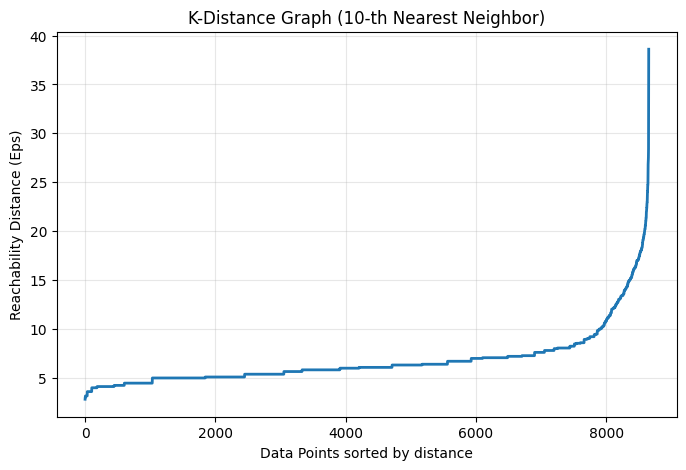


Eps ottimale stimato dal grafico (Elbow): 9.5


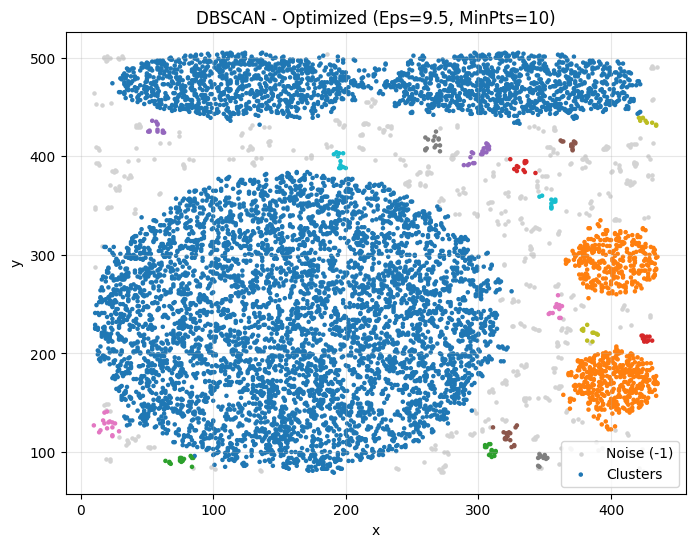

In [23]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# 1. Impostiamo MinPts a 10
minpts = 10 #

# 2. Calcoliamo la reachability distance del 10° vicino più prossimo
# Usiamo NearestNeighbors per trovare le distanze.
nn = NearestNeighbors(n_neighbors=minpts)
nn.fit(dataset3_sampled)
distances, indices = nn.kneighbors(dataset3_sampled)

# Estraiamo solo le distanze verso il decimo vicino (l'ultima colonna dell'array)
reachability_distances = distances[:, -1]

# 3. Ordiniamo le distanze in ordine crescente
sorted_reachability_distances = np.sort(reachability_distances)

# 4. Plottiamo le distanze ordinate (K-Distance Graph)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_reachability_distances, linewidth=2)
ax.set_title('K-Distance Graph (10-th Nearest Neighbor)')
ax.set_xlabel('Data Points sorted by distance')
ax.set_ylabel('Reachability Distance (Eps)')
ax.grid(alpha=0.3)
plt.show()

# 5. Individuazione dell'Elbow (Gomito)
# Il grafico mostrerà una curva piatta che a un certo punto si impenna bruscamente.
# Il punto in cui inizia la salita ripida (elbow) rappresenta l'Eps ottimale.
# Per questo dataset, il gomito si trova generalmente attorno a 9.0 - 10.0.
eps_optimal = 9.5
print(f"\nEps ottimale stimato dal grafico (Elbow): {eps_optimal}")

# 6. Testiamo la coppia combinata di parametri sul dataset con DBSCAN
dbscan_optimal = DBSCAN(eps=eps_optimal, min_samples=minpts)
labels_optimal = dbscan_optimal.fit_predict(dataset3_sampled)

# Plot del risultato ottimizzato
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.set_title(f'DBSCAN - Optimized (Eps={eps_optimal}, MinPts={minpts})')
ax.set_xlabel(feature_names3[0])
ax.set_ylabel(feature_names3[1])

noise_mask_opt = (labels_optimal == -1)

# Plottiamo prima il rumore
plt.scatter(dataset3_sampled[noise_mask_opt, 0], dataset3_sampled[noise_mask_opt, 1],
            s=5, c='lightgray', label='Noise (-1)')

# Plottiamo i cluster
plt.scatter(dataset3_sampled[~noise_mask_opt, 0], dataset3_sampled[~noise_mask_opt, 1],
            s=5, c=labels_optimal[~noise_mask_opt], cmap='tab10', label='Clusters')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Set *Minpts* to a number (say **10**) and compute the **reachability distance** of the **10-th nearest neighbour ** for each data-point.

In [26]:
from sklearn.neighbors import NearestNeighbors

# Calcolo della reachability distance per il 10° vicino
# Configuriamo l'algoritmo per cercare esattamente 10 vicini
nn = NearestNeighbors(n_neighbors=minpts)
nn.fit(dataset3_sampled)

# kneighbors restituisce una matrice con le distanze per tutti i 10 vicini di ogni punto
distances, indices = nn.kneighbors(dataset3_sampled)

# Estraiamo esclusivamente l'ultima colonna, che rappresenta la distanza dal 10° vicino
reachability_distances = distances[:, -1]

### 3. Sort the set of reachability distances you obtained in an increasing way.


In [27]:
# 3. Ordinamento delle distanze in ordine crescente
sorted_reachability_distances = np.sort(reachability_distances) #[cite: 1]

### 4. Plot the sorted reachability distances

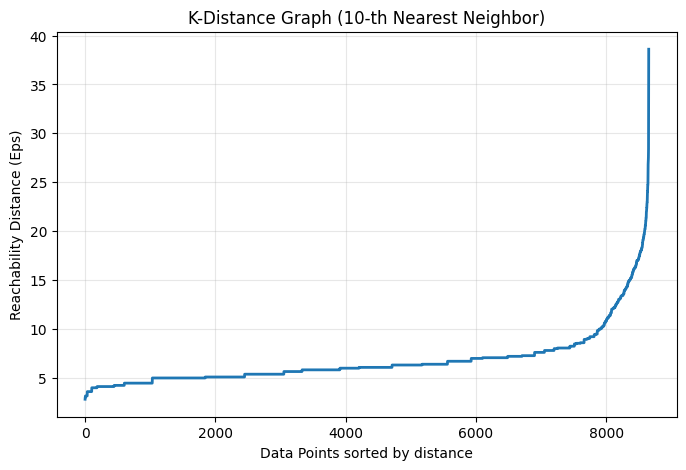

In [29]:
# Plot delle distanze di raggiungibilità ordinate[cite: 1]
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

# Creazione del grafico a linee
ax.plot(sorted_reachability_distances, linewidth=2)

# Personalizzazione di titoli ed etichette
ax.set_title('K-Distance Graph (10-th Nearest Neighbor)')
ax.set_xlabel('Data Points sorted by distance')
ax.set_ylabel('Reachability Distance (Eps)')
ax.grid(alpha=0.3)

plt.show()

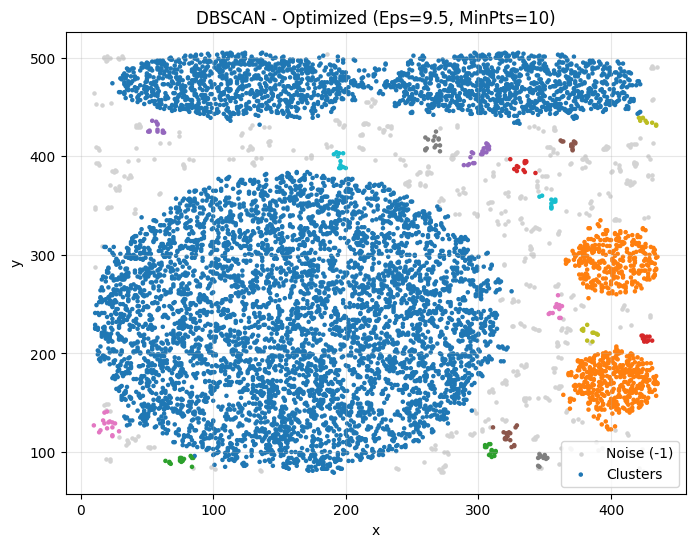

In [30]:
from sklearn.cluster import DBSCAN

# 6. Test della coppia di parametri sul dataset[cite: 1]
dbscan_optimal = DBSCAN(eps=eps_optimal, min_samples=minpts) #[cite: 1]
labels_optimal = dbscan_optimal.fit_predict(dataset3_sampled)

# Generazione del grafico finale
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.set_title(f'DBSCAN - Optimized (Eps={eps_optimal}, MinPts={minpts})')
ax.set_xlabel(feature_names3[0])
ax.set_ylabel(feature_names3[1])

# Separazione del rumore (etichetta -1) dai cluster validi
noise_mask_opt = (labels_optimal == -1)

# Plot del rumore in grigio chiaro
plt.scatter(dataset3_sampled[noise_mask_opt, 0], dataset3_sampled[noise_mask_opt, 1],
            s=5, c='lightgray', label='Noise (-1)')

# Plot dei cluster effettivi con colori distinti
plt.scatter(dataset3_sampled[~noise_mask_opt, 0], dataset3_sampled[~noise_mask_opt, 1],
            s=5, c=labels_optimal[~noise_mask_opt], cmap='tab10', label='Clusters')

plt.legend()
plt.grid(alpha=0.3)
plt.show()